### 1. Import Libraries

In [33]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/uber-pickups-in-new-york-city/uber-raw-data-may14.csv
/kaggle/input/uber-pickups-in-new-york-city/other-FHV-services_jan-aug-2015.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Prestige_B01338.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Firstclass_B01536.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Skyline_B00111.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Lyft_B02510.csv
/kaggle/input/uber-pickups-in-new-york-city/uber-raw-data-apr14.csv
/kaggle/input/uber-pickups-in-new-york-city/uber-raw-data-jul14.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Dial7_B00887.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Diplo_B01196.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Federal_02216.csv
/kaggle/input/uber-pickups-in-new-york-city/Uber-Jan-Feb-FOIL.csv
/kaggle/input/uber-pickups-in-new-york-city/uber-raw-data-jun14.csv
/kaggle/input/uber-pickups-in-new-york-city/other-Highclass_B01717.csv
/kaggle/input/uber-pickups-in-ne

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


import warnings
warnings.filterwarnings("ignore")

2026-03-07 04:18:51.643110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772857131.926866      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772857132.009552      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### 2. Load Dataset

In [4]:
files = []

# Get all uber rides raw data
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        files.append(os.path.join(dirname, filename)) if "raw" in filename else None
# Keep the jun- sep 2014 data on a separate list
files = files[:-1]

In [5]:
dataframes = [pd.read_csv(file) for file in files]

In [6]:
df = pd.concat(dataframes, ignore_index=True)
# Now make sure the date column is set to datetime, sorted and with an adequate name
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M:%S')
df = df.sort_values(by='Date/Time')
df = df.rename(columns={'Date/Time':'Date'})
df.set_index('Date',inplace=True)

In [7]:
df.head()

,Lat,Lon,Base
Date,,,
2014-04-01 00:00:00,40.7637,-73.9600,B02598
2014-04-01 00:00:00,40.7188,-73.9863,B02598
2014-04-01 00:00:00,40.7215,-73.9952,B02682
2014-04-01 00:01:00,40.7355,-73.9966,B02617
2014-04-01 00:02:00,40.7444,-73.9964,B02598


In [9]:
# Group by hour and count occurrences of 'Base'
hourly_counts = df['Base'].resample('h').count()

# Convert the series to a dataframe
df2 = hourly_counts.reset_index()

# Rename columns for clarity
df2.columns = ['Date', 'Count']
df2.set_index('Date',inplace=True)

**Inspect Data(shape and columns)**

In [8]:
df.shape

(4534327, 3)

In [10]:
# print("Shape of dataset:", df.shape)
# print("Columns:", df.columns)
# print(df.head())


**Rename columns for easier use**

In [11]:
df2.columns = df2.columns.str.strip().str.lower().str.replace(" ", "_")
df2.columns

Index(['count'], dtype='object')

In [12]:
df2.head()

,count
Date,
2014-04-01 00:00:00,138
2014-04-01 01:00:00,66
2014-04-01 02:00:00,53
2014-04-01 03:00:00,93
2014-04-01 04:00:00,166


In [13]:
df2.shape

(4391, 1)

**Check missing values & duplicates**

In [14]:
print("Missing values:\n", df.isnull().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Missing values:
 Lat     0
Lon     0
Base    0
dtype: int64
Shape after removing duplicates: (1252769, 3)


In [15]:
print("Missing values:\n", df2.isnull().sum())
df2 = df2.drop_duplicates()
print("Shape after removing duplicates:", df2.shape)

Missing values:
 count    0
dtype: int64
Shape after removing duplicates: (1964, 1)


**Handle datetime**

In [16]:
df['date'] = pd.to_datetime(df.index)
df['hour'] = df.index.hour     
df['day'] = df.index.day        
df['weekday'] = df.index.weekday
df['month'] = df.index.month

In [18]:
df.head()

,Lat,Lon,Base,date,hour,day,weekday,month
Date,,,,,,,,
2014-04-01 00:00:00,40.7637,-73.9600,B02598,2014-04-01 00:00:00,0,1,1,4
2014-04-01 00:00:00,40.7188,-73.9863,B02598,2014-04-01 00:00:00,0,1,1,4
2014-04-01 00:00:00,40.7215,-73.9952,B02682,2014-04-01 00:00:00,0,1,1,4
2014-04-01 00:01:00,40.7355,-73.9966,B02617,2014-04-01 00:01:00,0,1,1,4
2014-04-01 00:02:00,40.7444,-73.9964,B02598,2014-04-01 00:02:00,0,1,1,4


### 3: Detailed EDA

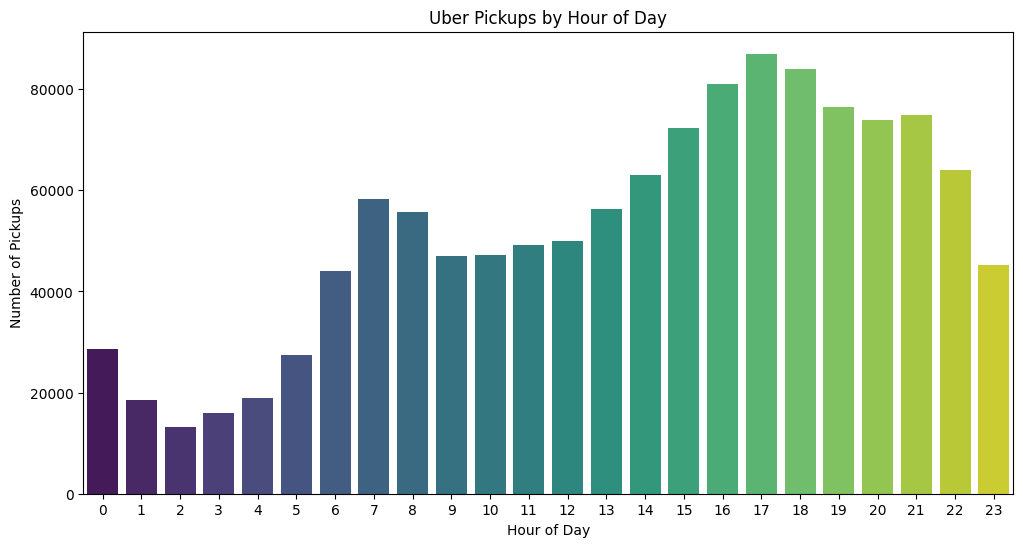

In [19]:
# Pickups by Hour
plt.figure(figsize=(12,6))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title("Uber Pickups by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.show()


As we see clearly number of pickups peaks at 17:00 

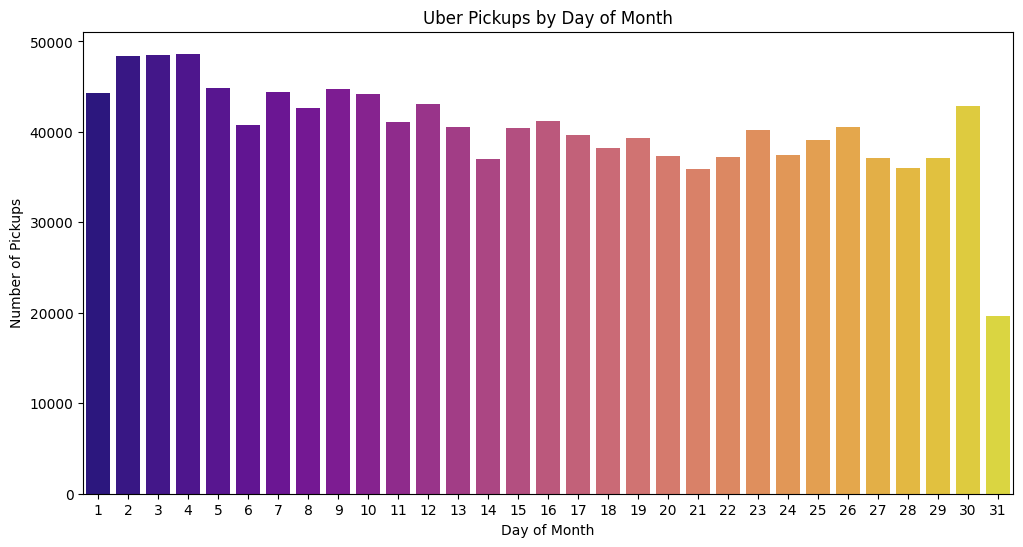

In [20]:
# Pickups by Day
plt.figure(figsize=(12,6))
sns.countplot(x='day', data=df, palette='plasma')
plt.title("Uber Pickups by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Number of Pickups")
plt.show()


The start of the month has higher pickup rates.

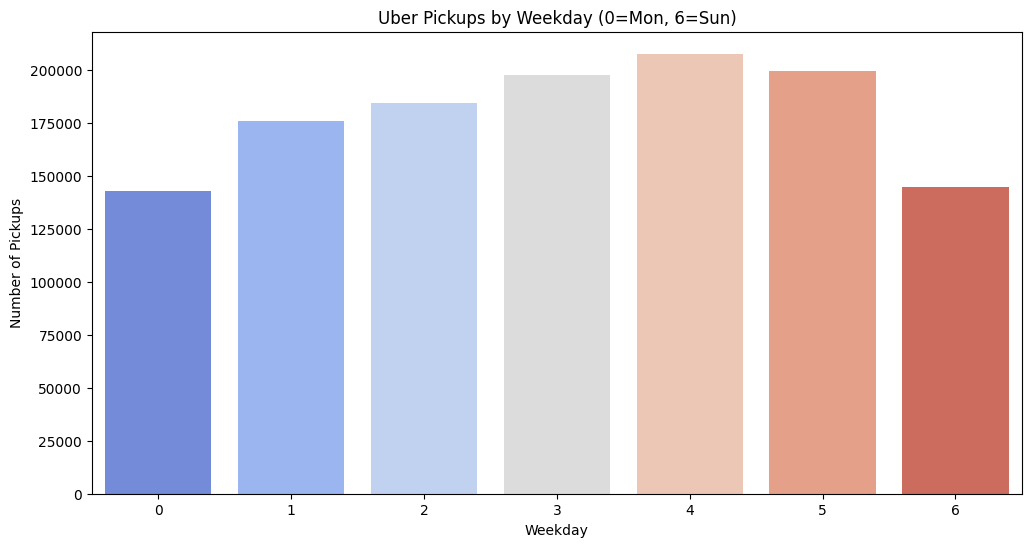

In [21]:
# Pickups by Weekday
plt.figure(figsize=(12,6))
sns.countplot(x='weekday', data=df, palette='coolwarm')
plt.title("Uber Pickups by Weekday (0=Mon, 6=Sun)")
plt.xlabel("Weekday")
plt.ylabel("Number of Pickups")
plt.show()

Clearly, Sunday has very less number of pickups than the other days.

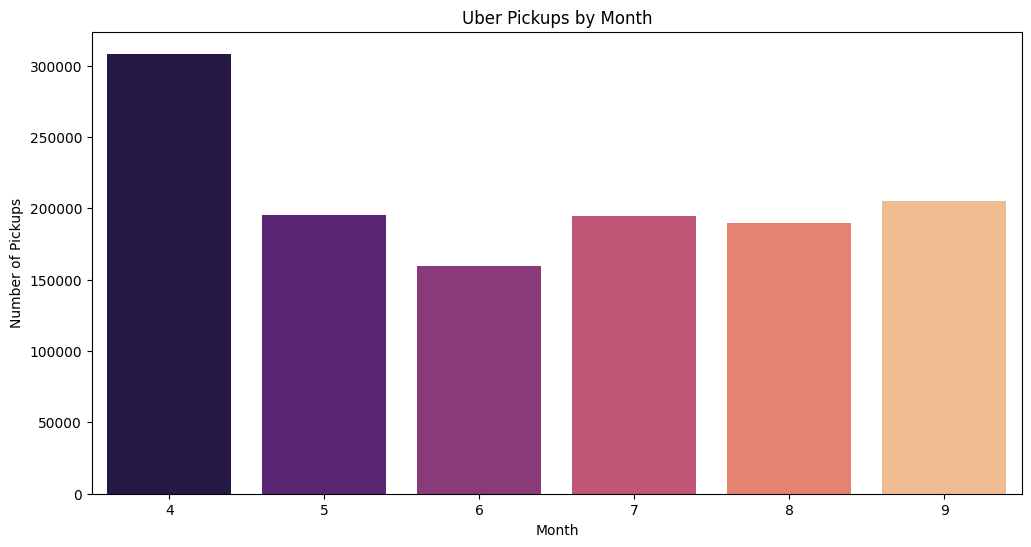

In [22]:
# Pickups by Month
plt.figure(figsize=(12,6))
sns.countplot(x='month', data=df, palette='magma')
plt.title("Uber Pickups by Month")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.show()

April is having higher pickups

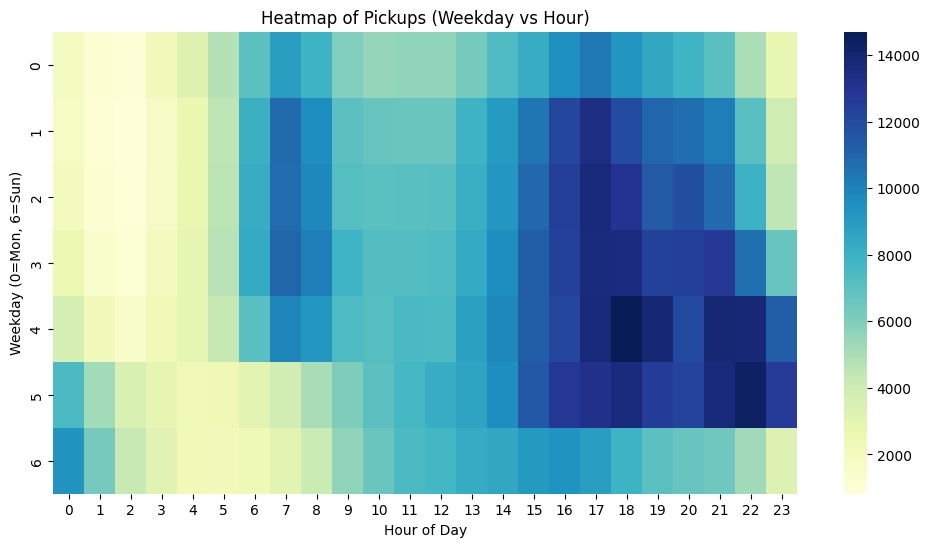

In [23]:
# Heatmap of pickups by hour and weekday
heatmap_data = df.groupby(['weekday', 'hour']).size().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Heatmap of Pickups (Weekday vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday (0=Mon, 6=Sun)")
plt.show()

We can observe that the busiest time is around 15:00 to 21:00 hrs, and higher pickup rates in the morning, i.e., between 6 and 8 hrs.

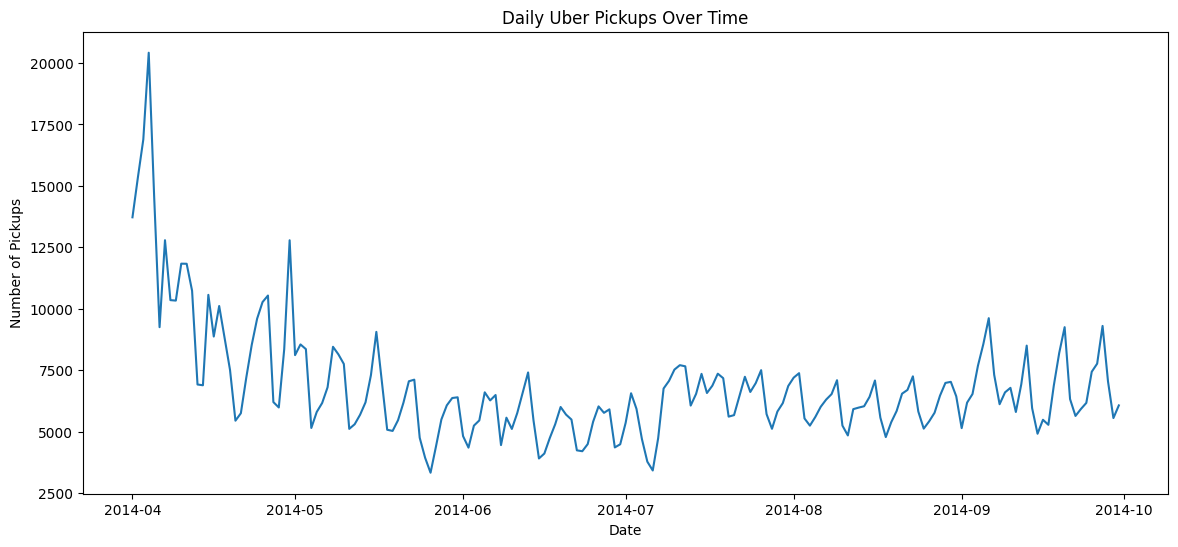

In [24]:
# Daily trends
daily_pickups = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(14,6))
daily_pickups.plot()
plt.title("Daily Uber Pickups Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Pickups")
plt.show()

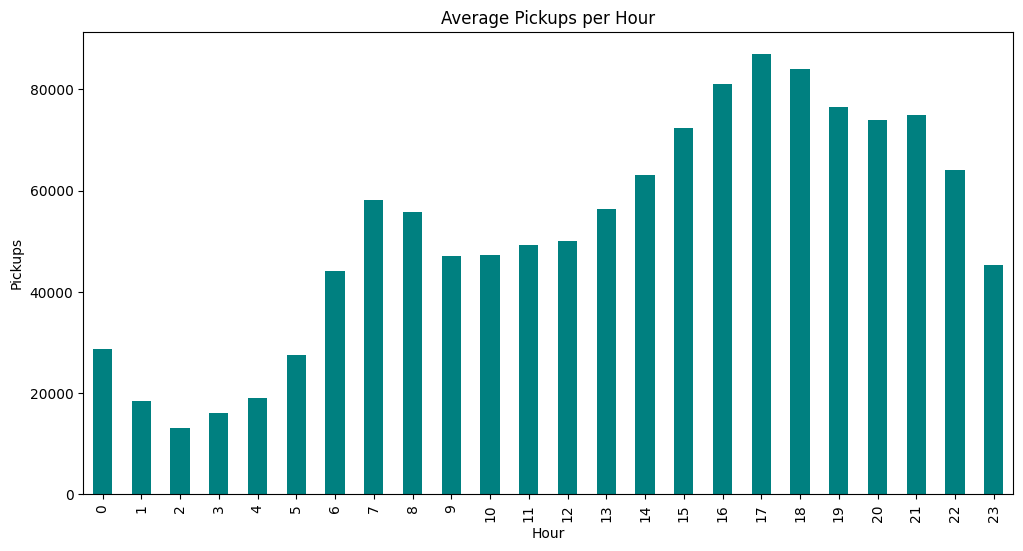

In [25]:
# Hourly average over full dataset
hourly_avg = df.groupby('hour').size()
plt.figure(figsize=(12,6))
hourly_avg.plot(kind='bar', color='teal')
plt.title("Average Pickups per Hour")
plt.xlabel("Hour")
plt.ylabel("Pickups")
plt.show()

17:00 O'clock having the maximum number of average pickups

In [26]:
# Sample 50,000 rows for faster plotting
df_sample = df.sample(50000, random_state=42)
df_sample.head()

,Lat,Lon,Base,date,hour,day,weekday,month
Date,,,,,,,,
2014-08-27 22:53:00,40.7336,-73.9581,B02598,2014-08-27 22:53:00,22,27,2,8
2014-09-21 16:43:00,40.7680,-73.9523,B02598,2014-09-21 16:43:00,16,21,6,9
2014-07-05 03:32:00,40.7115,-74.0062,B02617,2014-07-05 03:32:00,3,5,5,7
2014-09-24 12:17:00,40.7355,-73.9878,B02682,2014-09-24 12:17:00,12,24,2,9
2014-06-05 18:41:00,40.7600,-74.0025,B02682,2014-06-05 18:41:00,18,5,3,6


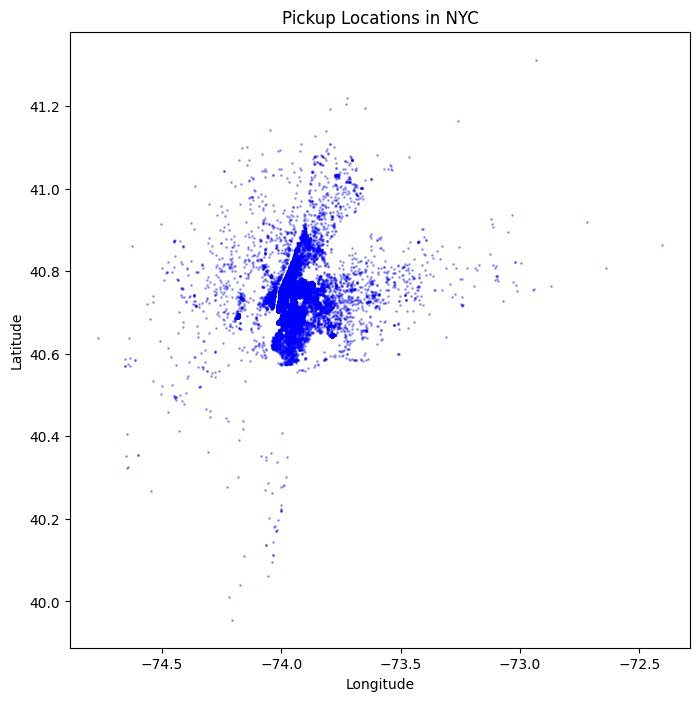

In [27]:
plt.figure(figsize=(8,8))
plt.scatter(df_sample['Lon'], df_sample['Lat'], s=1, alpha=0.3, c='blue')
plt.title("Pickup Locations in NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Plotting The mapbox: 

In [40]:
import plotly.express as px

fig = px.scatter_mapbox(
    df_sample, 
    lat='Lat', 
    lon='Lon', 
    zoom=11,
    height=600,
    opacity=0.3,
    size_max=1  # use fixed small size
)
fig.update_layout(mapbox_style="open-street-map")  # or "carto-positron", "stamen-terrain", etc.
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

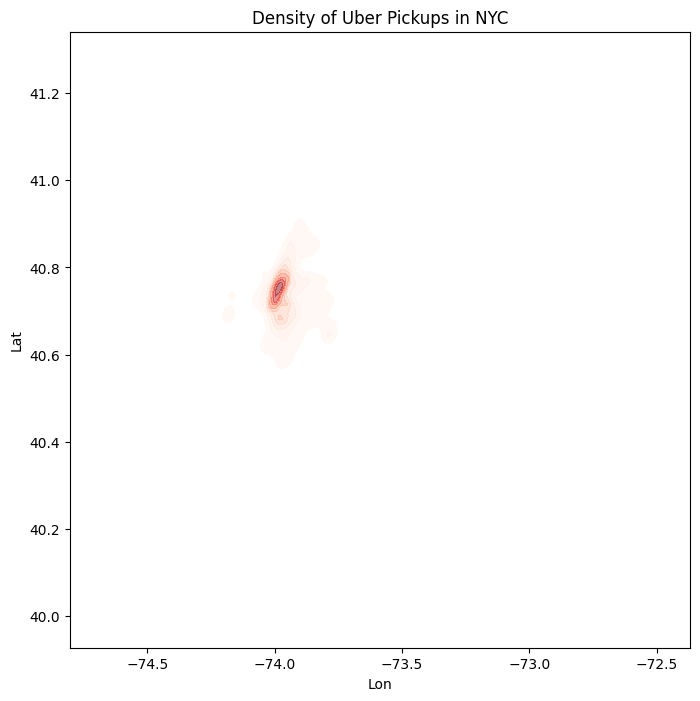

In [29]:
# Density plot
plt.figure(figsize=(8,8))
sns.kdeplot(x=df_sample['Lon'], y=df_sample['Lat'], cmap="Reds", fill=True, alpha=0.5)
plt.title("Density of Uber Pickups in NYC")
plt.show()

In [30]:
# Interactive plot of pickups by hour
hourly_data = df.groupby('hour').size().reset_index(name='pickups')

fig = px.bar(hourly_data, x='hour', y='pickups',
             title="Uber Pickups by Hour (Interactive)",
             labels={'hour':'Hour of Day', 'pickups':'Number of Pickups'},
             template="plotly_dark")
fig.show()


In [31]:
# Interactive plot of pickups by weekday
weekday_data = df.groupby('weekday').size().reset_index(name='pickups')
fig = px.bar(weekday_data, x='weekday', y='pickups',
             title="Uber Pickups by Weekday (Interactive)",
             labels={'weekday':'Weekday (0=Mon, 6=Sun)', 'pickups':'Number of Pickups'},
             template="plotly_dark")
fig.show()

In [34]:
# Aggregate by date and hour
df['date'] = df['date'].dt.date
df['hour_str'] = df['hour'].astype(str) + ":00"

agg = df.groupby(['date','hour']).size().reset_index(name='pickups')

fig = px.line(agg, x="hour", y="pickups", animation_frame="date",
              title="Animated Hourly Pickup Trends Over Days",
              labels={'hour':'Hour of Day', 'pickups':'Number of Pickups'})
fig.show()

In [35]:
# Weekend flag (Saturday=5, Sunday=6, Monday=0....)
df['is_weekend'] = df['weekday'].isin([5, 6])

df.index = pd.to_datetime(df.index)   # if not already

# Rush hour flag (7–10 AM, 4–7 PM)
df['is_rush_hour'] = df['hour'].between(7, 9) | df['hour'].between(17, 19)

df['day_of_year'] = df.index.dayofyear  # Day of year
df['week_of_year'] = df.index.isocalendar().week   # Week of year

In [36]:
df.head()

,Lat,Lon,Base,date,hour,day,weekday,month,hour_str,is_weekend,is_rush_hour,day_of_year,week_of_year
Date,,,,,,,,,,,,,
2014-04-01 00:00:00,40.7637,-73.9600,B02598,2014-04-01,0,1,1,4,0:00,False,False,91,14
2014-04-01 00:00:00,40.7188,-73.9863,B02598,2014-04-01,0,1,1,4,0:00,False,False,91,14
2014-04-01 00:00:00,40.7215,-73.9952,B02682,2014-04-01,0,1,1,4,0:00,False,False,91,14
2014-04-01 00:01:00,40.7355,-73.9966,B02617,2014-04-01,0,1,1,4,0:00,False,False,91,14
2014-04-01 00:02:00,40.7444,-73.9964,B02598,2014-04-01,0,1,1,4,0:00,False,False,91,14


                         Lat      Lon    Base        date  hour  day  weekday  \
Date                                                                            
2014-04-01 00:00:00  40.7637 -73.9600  B02598  2014-04-01     0    1        1   
2014-04-01 00:00:00  40.7188 -73.9863  B02598  2014-04-01     0    1        1   
2014-04-01 00:00:00  40.7215 -73.9952  B02682  2014-04-01     0    1        1   
2014-04-01 00:01:00  40.7355 -73.9966  B02617  2014-04-01     0    1        1   
2014-04-01 00:02:00  40.7444 -73.9964  B02598  2014-04-01     0    1        1   

                     month hour_str  is_weekend  is_rush_hour  day_of_year  \
Date                                                                         
2014-04-01 00:00:00      4     0:00       False         False           91   
2014-04-01 00:00:00      4     0:00       False         False           91   
2014-04-01 00:00:00      4     0:00       False         False           91   
2014-04-01 00:01:00      4     0:00       

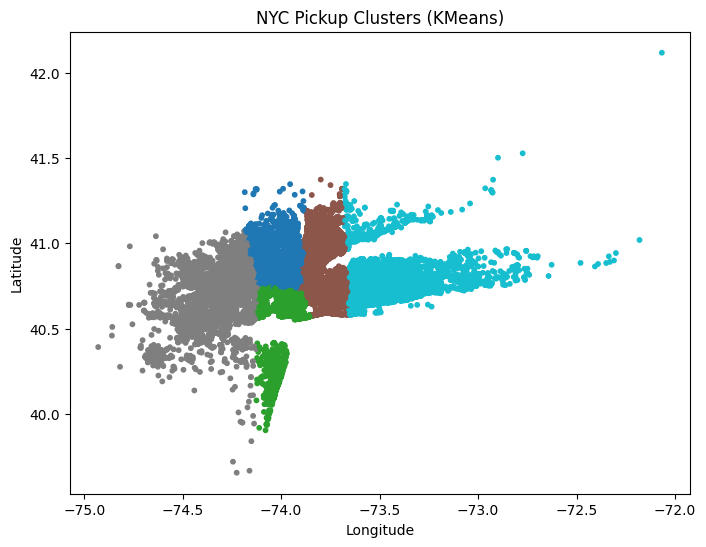

In [37]:
from math import radians, cos, sin, asin, sqrt
from sklearn.cluster import KMeans

# distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Earth radius (km)
    return c * r

# Distance from NYC center
nyc_lat, nyc_lon = 40.7128, -74.0060
df['distance_from_center'] = df.apply(lambda row: haversine(nyc_lon, nyc_lat, row['Lon'], row['Lat']), axis=1)

# KMeans on a sample
df_sample = df.sample(20000, random_state=42)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_sample[['Lat','Lon']])

# Assign clusters
df['pickup_cluster'] = kmeans.predict(df[['Lat','Lon']])


print(df.head())


print("\nUnique clusters:", df['pickup_cluster'].unique())

print("\nCluster counts:")
print(df['pickup_cluster'].value_counts())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Lon'], df['Lat'], c=df['pickup_cluster'], cmap='tab10', s=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('NYC Pickup Clusters (KMeans)')
plt.show()

In [38]:
df['date'] = pd.to_datetime(df['date'])


hourly_demand = df.groupby(df['date'].dt.floor('h')).size().reset_index(name='pickups')
hourly_demand.rename(columns={'date': 'date_hour'}, inplace=True)

# Extract time
hourly_demand['hour'] = hourly_demand['date_hour'].dt.hour
hourly_demand['day'] = hourly_demand['date_hour'].dt.day
hourly_demand['weekday'] = hourly_demand['date_hour'].dt.weekday      # Monday=0, Sunday=6
hourly_demand['month'] = hourly_demand['date_hour'].dt.month

# weekend flag
hourly_demand['is_weekend'] = hourly_demand['weekday'].isin([5, 6]).astype(int)

# day of year and week of year
hourly_demand['day_of_year'] = hourly_demand['date_hour'].dt.dayofyear
hourly_demand['week_of_year'] = hourly_demand['date_hour'].dt.isocalendar().week

hourly_demand.head()

,date_hour,pickups,hour,day,weekday,month,is_weekend,day_of_year,week_of_year
0,2014-04-01,13722,0,1,1,4,0,91,14
1,2014-04-02,15346,0,2,2,4,0,92,14
2,2014-04-03,16891,0,3,3,4,0,93,14
3,2014-04-04,20421,0,4,4,4,0,94,14
4,2014-04-05,14571,0,5,5,4,1,95,14


In [39]:
# Create demand categories
q1 = hourly_demand['pickups'].quantile(0.25)
q3 = hourly_demand['pickups'].quantile(0.75)

def categorize_demand(x):
    if x <= q1:
        return "Low"
    elif x <= q3:
        return "Medium"
    else:
        return "High"

hourly_demand['demand_category'] = hourly_demand['pickups'].apply(categorize_demand)
hourly_demand.head()

,date_hour,pickups,hour,day,weekday,month,is_weekend,day_of_year,week_of_year,demand_category
0,2014-04-01,13722,0,1,1,4,0,91,14,High
1,2014-04-02,15346,0,2,2,4,0,92,14,High
2,2014-04-03,16891,0,3,3,4,0,93,14,High
3,2014-04-04,20421,0,4,4,4,0,94,14,High
4,2014-04-05,14571,0,5,5,4,1,95,14,High


### 4. Select optimal split into train and test sets (For Seasonal Predictions)

To choose the correct train/test sets, we first visualise the series and then perform a seasonal decomposition. If the trend can inform us of a suggested approach to that split

In [49]:
print(df.index.min())
print(df.index.max())

2014-04-01 00:00:00
2014-09-30 22:59:00


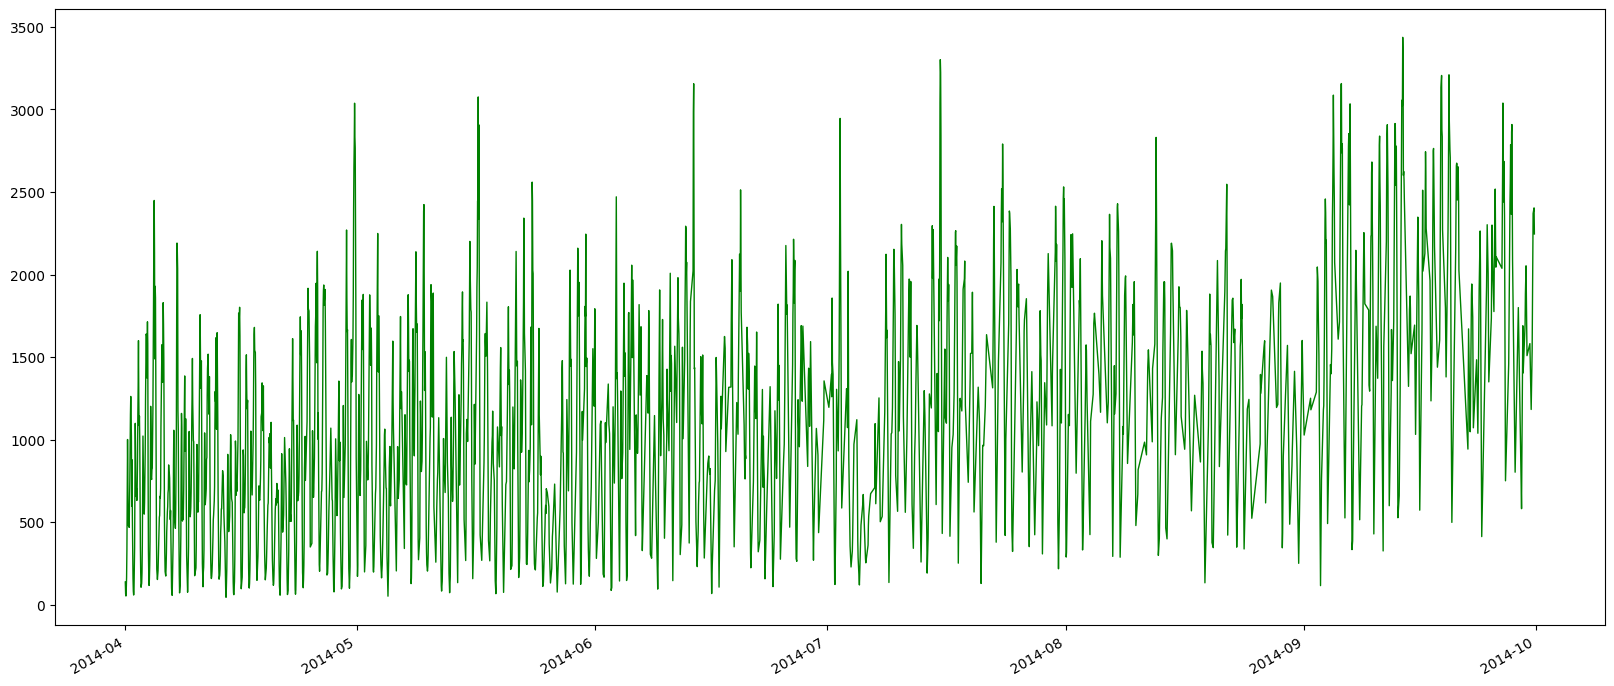

In [54]:
# Let's plot the series
plt.figure(figsize=(20, 8))
plt.plot(df2['count'],linewidth = 1, color='green')
plt.xticks(rotation=30,ha='right')
plt.show()

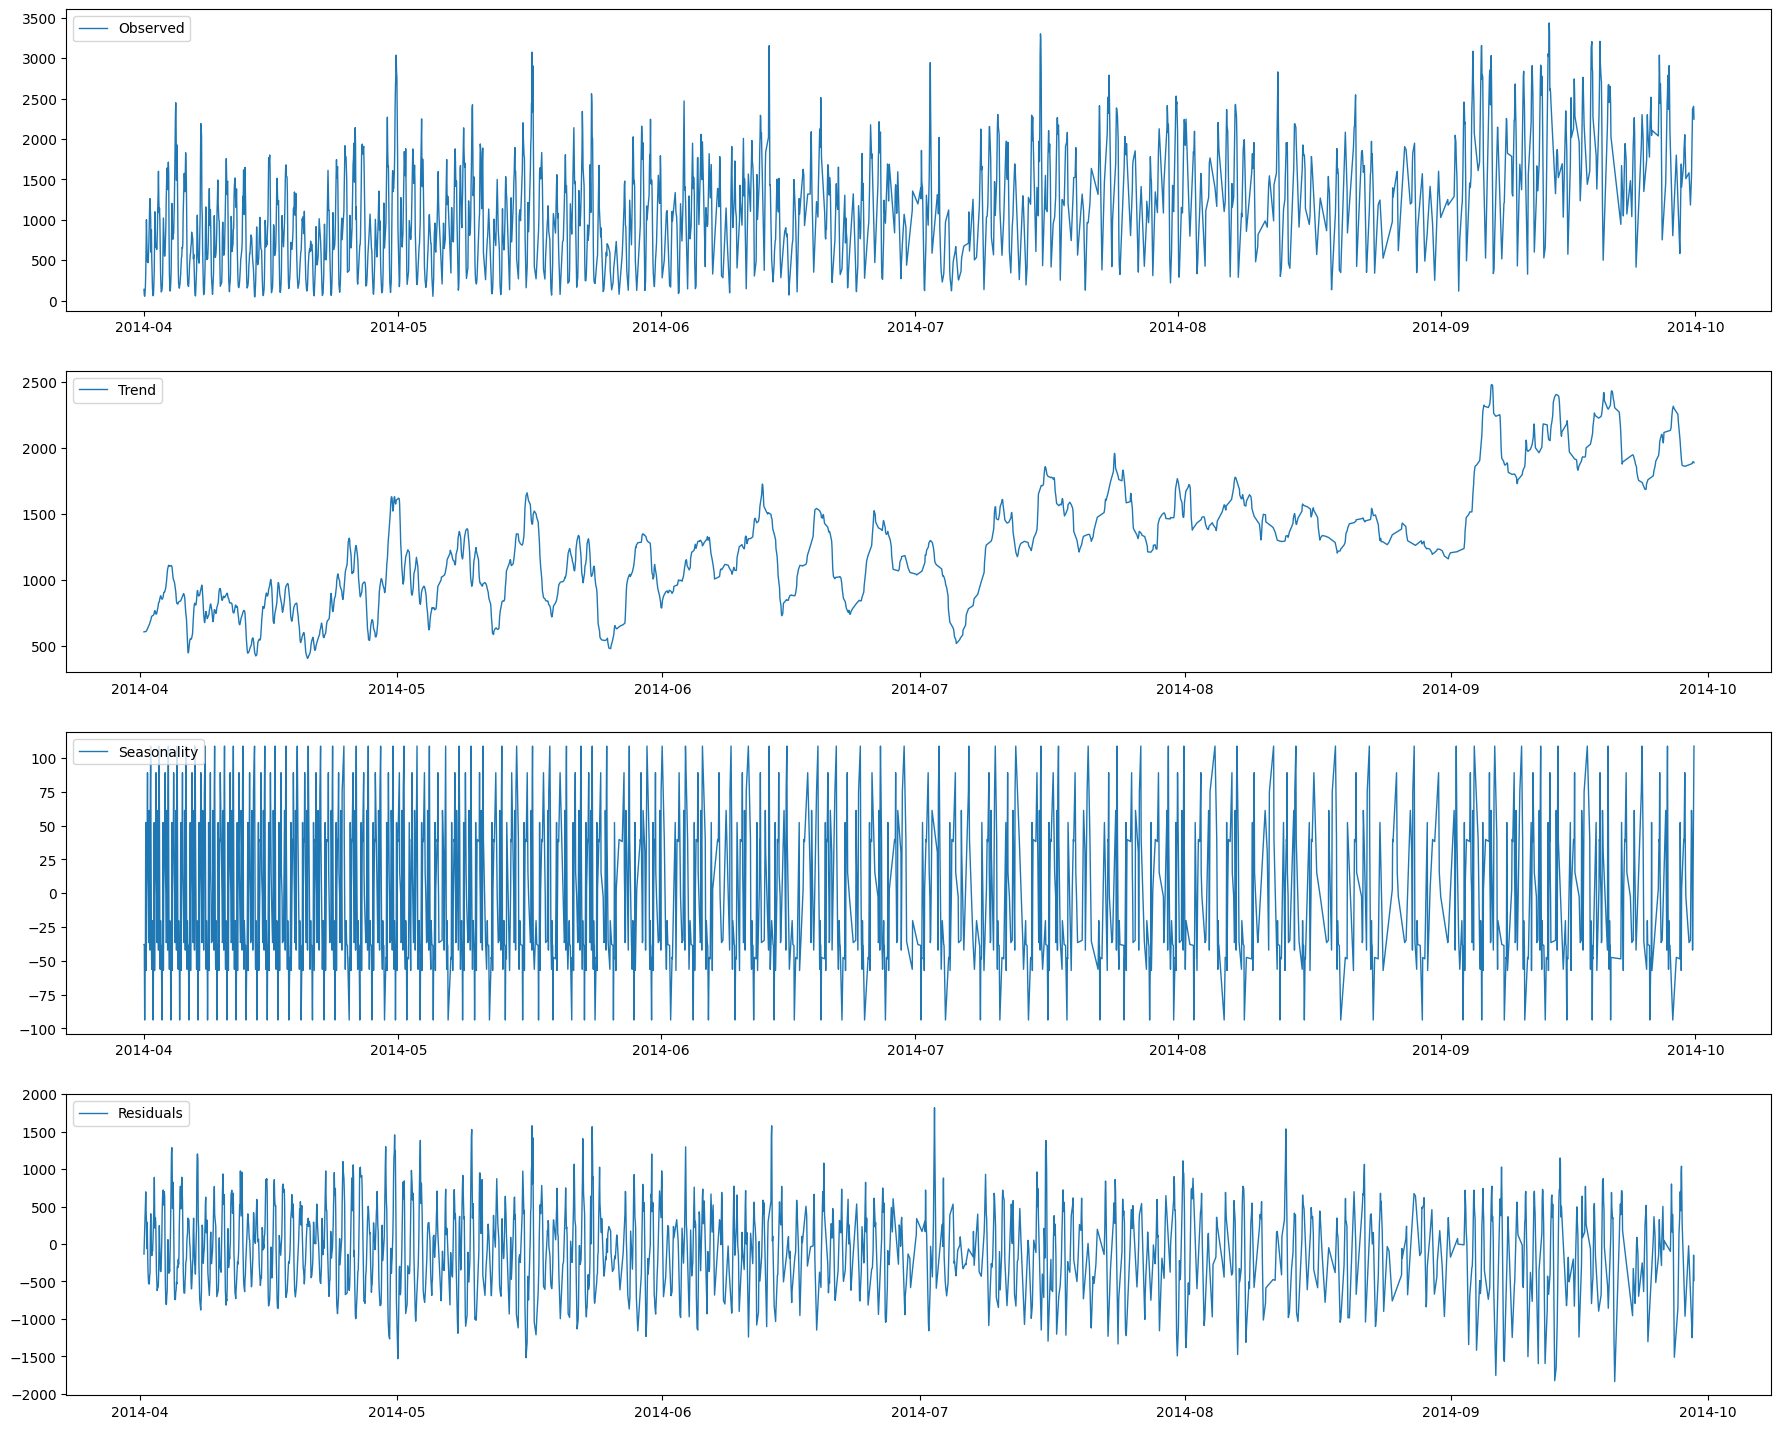

In [57]:
from statsmodels.tsa.seasonal import seasonal_decompose
def PlotDecomposition(result):
    plt.figure(figsize=(22,18))
    plt.subplot(4,1,1)
    plt.plot(result.observed,label='Observed',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4,1,2)
    plt.plot(result.trend,label='Trend',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 3)
    plt.plot(result.seasonal, label='Seasonality',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 4)
    plt.plot(result.resid, label='Residuals',lw=1)
    plt.legend(loc='upper left')
    plt.show()
result=seasonal_decompose(df2['count'],model='add', period=24*1)
PlotDecomposition(result)

The decomposition shows a constant trend, indicating no long-term increase or decrease in the series. The seasonal component closely matches the observed values, confirming strong seasonal fluctuations. However, the residuals display a declining pattern from July onward, suggesting that the model may be missing some underlying structure or that additional factors are influencing the data.

Let us analyse further

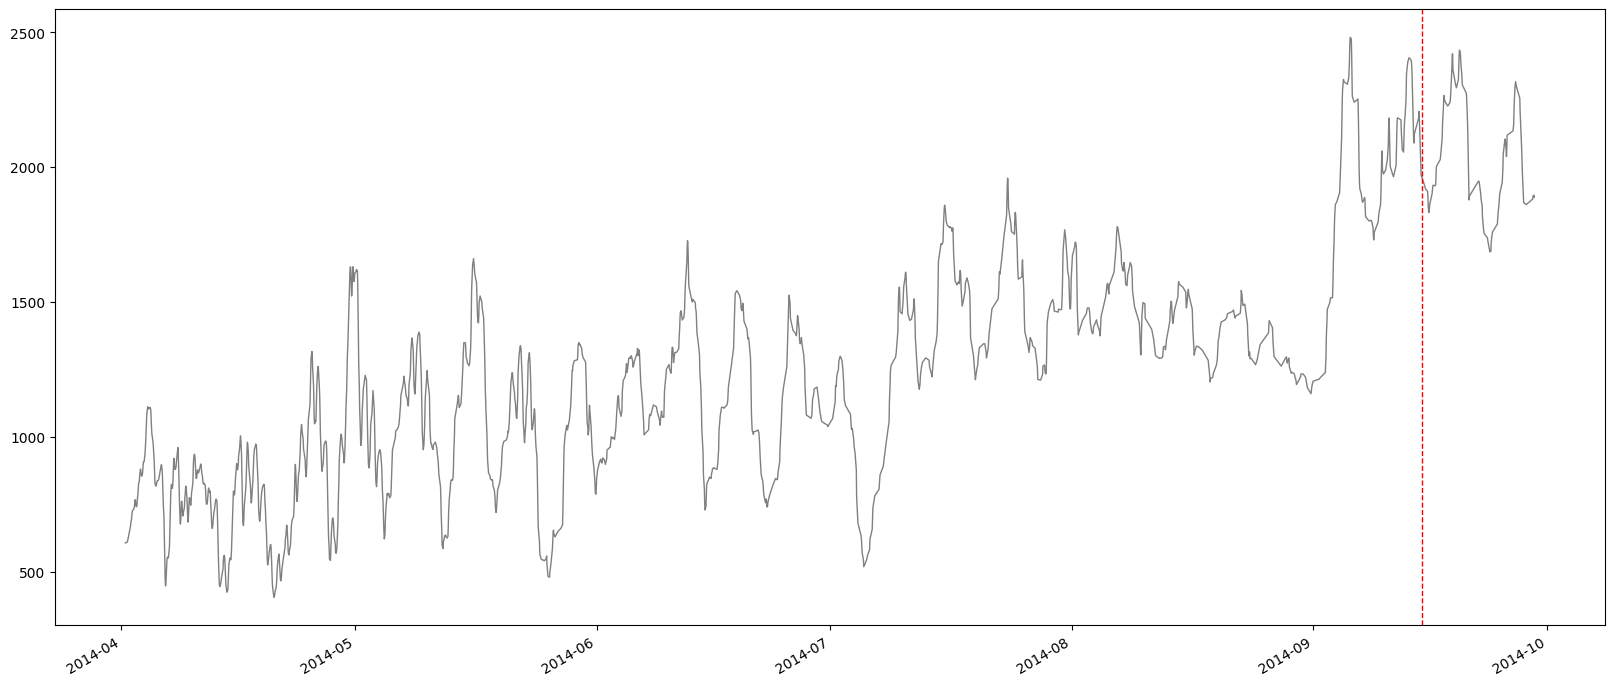

In [58]:
cutoff_date = '2014-09-15 00:00:00'
plt.figure(figsize=(20, 8))
plt.plot(result.trend,linewidth = 1, color='gray')
plt.axvline(x=pd.Timestamp(cutoff_date), color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=30,ha='right')
plt.show()

As seen above, the trend stays relatively stable until around September 2014, and then increases to 4 more peaks. Leaving up to the first 2 peaks as train data and the remaining 2 as test would be sufficient. This is particularly important, because if we did the usual 80/20 split, we would likely encounter errors due to the said trend increase.

In [59]:
seasonal_train = df.loc[:cutoff_date]
seasonal_test = df.loc[cutoff_date:]

In [71]:
plot_data = (
    seasonal_test.rename(columns={'count': 'TESTSET'})[['TESTSET']]
    .join(
        seasonal_train.rename(columns={'count': 'TRAINING SET'})[['TRAINING SET']],
        how='outer'
    )
)
plot_data.plot(figsize=(15,5), title='Train / Test Sets', style='-', lw=1)

KeyError: "None of [Index(['TESTSET'], dtype='object')] are in the [columns]"

### 4B. Select features, and select optimal split into train and test sets(For Hourly Predictions)

In [42]:
# Select features
features = ['hour','day','weekday','month','is_weekend']
X = hourly_demand[features]
y = hourly_demand['pickups']

In [43]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (146, 5) Test shape: (37, 5)


### 5. Build Linear Regression, Random Forest, XGBoost Model and Evaluated models using MAE, RMSE, R²

**Build a Linear Regression Model**

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R² Score:", r2_score(y_test, y_pred_lr))

Linear Regression Performance:
MAE: 1364.306099101051
RMSE: 1826.8305748307278
R² Score: 0.2171339658594975


The model explains only 21.7% of the variance in the target (R² = 0.217), indicating a weak fit. The high MAE and RMSE values (1364 and 1827) show substantial prediction errors, with RMSE exceeding MAE, suggesting the presence of outliers or large deviations. Overall, linear regression performs poorly on this dataset, implying that more complex models or additional features may be needed.

**Build a Random Forest Model**

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² Score:", r2_score(y_test, y_pred_rf))

Random Forest Performance:
MAE: 762.8998648648648
RMSE: 1110.4053811203123
R² Score: 0.7107628835044698


The Random Forest model shows a dramatic improvement over Linear Regression. With an R² of 0.711, it now explains 71% of the variance in the target, indicating a strong fit. The errors have also been nearly halved (MAE dropped from 1364 to 763, RMSE from 1827 to 1110), meaning predictions are much more accurate on average. This confirms that the relationship between features and target is non-linear and complex, which Random Forest captures effectively.

**Build a XGBoost Model**

In [ ]:
xgb_param_grid = {
'n_estimators': [100, 200, 300],
'max_depth': [3, 6, 9],
'learning_rate': [0.01, 0.1, 0.3],
'subsample': [0.6, 0.8, 1.0],
'colsample_bytree': [0.6, 0.8, 1.0]
}

In [48]:
xg_reg = xgb.XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xg_reg.fit(X_train, y_train)

y_pred_xgb = xg_reg.predict(X_test)

print("XGBoost Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R² Score:", r2_score(y_test, y_pred_xgb))

XGBoost Performance:
MAE: 652.3978304476351
RMSE: 1013.9559688656647
R² Score: 0.7588267699160729


XGBoost has delivered the best performance so far, improving upon an already strong Random Forest model. With an R² of 0.759, it explains nearly 76% of the variance in your target variable. The errors have also decreased further, making this your most accurate and reliable model to date.

# Step 7: Compare model performances

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression','Random Forest','XGBoost'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

print(results)

# Step 8: Encoded demand categories for classification

In [ ]:
# Encode demand categories
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
hourly_demand['demand_encoded'] = le.fit_transform(hourly_demand['demand_category'])

X = hourly_demand[features]
y = hourly_demand['demand_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 9:Trained and compared Random Forest and XGBoost models using accuracy and confusion matrices.


**Step 9.1: Random Forest classifier model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf_rf = RandomForestClassifier(n_estimators=200, random_state=42)
clf_rf.fit(X_train, y_train)

y_pred_rf = clf_rf.predict(X_test)

print("Random Forest Classification Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

**Step 9.2: XGBoost Classification model**

In [ ]:
clf_xgb = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
clf_xgb.fit(X_train, y_train)

y_pred_xgb = clf_xgb.predict(X_test)

print("XGBoost Classification Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Step 10:Prepared and scaled hourly demand data, created 24-hour LSTM sequences, and split into train-test sets

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Use hourly_demand time series
data = hourly_demand[['date_hour','pickups']].set_index('date_hour')

# Scale values
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(dataset, time_steps=24):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i+time_steps), 0])
        y.append(dataset[i+time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 24  # use past 24 hours to predict next hour
X, y = create_sequences(scaled_data, time_steps)

# Reshape for LSTM (samples, time_steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

 # Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)

# Step 11: Built LSTM model with 2 layers and dropout, and trained for 10 epochs

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_steps,1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

# Train
history = model_lstm.fit(X_train, y_train, validation_data=(X_test,y_test),
                         epochs=10, batch_size=32, verbose=1)

# Step 12: Visualize predicted vs actual pickups

In [ ]:
# Predictions
y_pred = model_lstm.predict(X_test)
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1,1))

# Plot
plt.figure(figsize=(14,6))
plt.plot(y_test_rescaled, label="Actual")
plt.plot(y_pred_rescaled, label="Predicted")
plt.title("LSTM - Demand Forecasting")
plt.xlabel("Time (hours)")
plt.ylabel("Pickups")
plt.legend()
plt.show()

# Step 13:Preprocess features and one-hot encode target to build an ANN model

In [ ]:
# Use demand classification dataset
X = hourly_demand[features].values
y = hourly_demand['demand_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode target
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

# Step 14:Built ANN classifier with dense and dropout layers and trained for 15 epochs

In [ ]:
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_ann.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train
history = model_ann.fit(X_train, y_train_cat,
                        validation_data=(X_test, y_test_cat),
                        epochs=15, batch_size=32, verbose=1)

# Step 15: Evaluated classification accuracy and generated confusion matrix


In [ ]:
# Evaluate
loss, acc = model_ann.evaluate(X_test, y_test_cat, verbose=0)
print("ANN Classification Accuracy:", acc)

# Predictions
y_pred = model_ann.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - ANN Classifier")
plt.show()

# Step 16: Compare model performances

In [ ]:
# Bar chart for Regression Models
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="RMSE", data=results, palette="coolwarm")
plt.title("Regression Models - RMSE Comparison")
plt.ylabel("Root Mean Squared Error")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R2", data=results, palette="viridis")
plt.title("Regression Models - R² Comparison")
plt.ylabel("R² Score")
plt.show()

# Step 17: Compared ANN performance with Random Forest and XGBoost

In [ ]:
# Collect classification results
clf_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'ANN'],
    'Accuracy': [
        accuracy_score(y_test, clf_rf.predict(X_test)),
        accuracy_score(y_test, clf_xgb.predict(X_test)),
        acc
    ]
})

print(clf_results)

# Plot accuracy comparison
plt.figure(figsize=(8,6))
sns.barplot(x="Model", y="Accuracy", data=clf_results, palette="magma")
plt.title("Classification Models - Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Step 18:Evaluate LSTM  using RMSE and R²

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae_lstm = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse_lstm = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))

print("LSTM Performance:")
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)

In [ ]:
# Compare RF vs XGBoost vs LSTM predictions (sample)
plt.figure(figsize=(14,6))
plt.plot(y_test_rescaled[:200], label="Actual", linewidth=2)
plt.plot(y_pred_rescaled[:200], label="LSTM Predicted", linestyle='--')
plt.title("Actual vs Predicted (LSTM, sample 200 hours)")
plt.xlabel("Time Steps")
plt.ylabel("Pickups")
plt.legend()
plt.show()

# Step 19: Analyzed feature importance for Random Forest and XGBoost 

In [ ]:
# Feature Importance - Random Forest
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature':features, 'Importance':importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="Blues")
plt.title("Feature Importance - Random Forest")
plt.show()

# Feature Importance - XGBoost
xgb.plot_importance(xg_reg, importance_type='weight', title="Feature Importance - XGBoost", height=0.5)
plt.show()

# Step 20: Explored demand trends by hour, weekday, and location clusters

In [ ]:
# Average pickups by hour
avg_by_hour = df.groupby('hour').size().reset_index(name='pickups')
print("Busiest Hours:\n", avg_by_hour.sort_values(by='pickups', ascending=False).head())

# Average pickups by weekday
avg_by_weekday = df.groupby('weekday').size().reset_index(name='pickups')
print("\nBusiest Days of the Week (0=Mon, 6=Sun):\n", avg_by_weekday.sort_values(by='pickups', ascending=False))

# Top locations (clusters)
if 'pickup_cluster' in df.columns:
    cluster_counts = df['pickup_cluster'].value_counts()
    print("\nPickup Hotspot Clusters:\n", cluster_counts)

# Step 21: Finding best regression model

In [ ]:
best_reg = results.sort_values(by='RMSE').iloc[0]
print(f"\nBest Regression Model: {best_reg['Model']}")
print(f"RMSE: {best_reg['RMSE']:.2f}, R²: {best_reg['R2']:.3f}")

# Step 22: Finding best classification model

In [ ]:

best_clf = clf_results.sort_values(by='Accuracy').iloc[-1]
print(f"\nBest Classification Model: {best_clf['Model']}")
print(f"Accuracy: {best_clf['Accuracy']:.3f}")

In [ ]:
# Random Forest feature importance (only if model trained)
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by="Importance", ascending=False)
print("\nFeature Importance (Random Forest):\n", feat_imp)

# Step 23:Visualized trends using line plots and bar charts 

In [ ]:
# Plot average demand by hour and weekday
plt.figure(figsize=(12,6))
sns.lineplot(x='hour', y='pickups', data=avg_by_hour, marker="o")
plt.title("Average Pickups by Hour")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x='weekday', y='pickups', data=avg_by_weekday, palette="coolwarm")
plt.title("Average Pickups by Weekday (0=Mon, 6=Sun)")
plt.show()
